<H1>Bayesian Linear Regression Using TensorFlow Probability</H1>

Classic frequentist linear regression modeling generally involves estimating the parameters $\beta$ and $\sigma$ of a linear model using various methods such as ordinary least squares.<br>




$Y_{i}=\mathop{\mathbb{E}}\left[Y_{i}\right]+\epsilon_{i}$<br>
$Y=\mathop{\mathbb{E}}\left[Y\right]+\epsilon$<br>
$\text{where }\epsilon\sim\mathcal{N}\left(\mu,\sigma^{2}\right)$<br>

$Y=X\beta+\epsilon$<br>

 $\hat{Y_{i}}=\hat{y_{i}}=\beta X +\epsilon$<br>

$\hat{y_{i}}\sim\mathcal{N}(\hat{\beta} X ,]\hat{\sigma}^{2}I)$<br>

$P(Y_{i}=y_{i}|X_{i}=x_{i}, \beta=\hat{\beta}, \sigma=\hat{\sigma}^{2})$<br>

In [2]:
import matplotlib.pyplot as plt
import numpy as np

In [3]:
import tensorflow as tf
import tensorflow_probability as tfp

print('TF version:', tf.__version__)
print('TFP version:', tfp.__version__)

2025-08-15 02:20:21.109651: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-15 02:20:21.146989: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TF version: 2.20.0
TFP version: 0.25.0


<H1>Data Generation</H1>

Create a training set that reprents the following function:<br>
$y_{i}=x_{i}+\text{c}\epsilon_{i}\quad\quad\quad\text{where c }\in\left(0, 1\right]$<br>

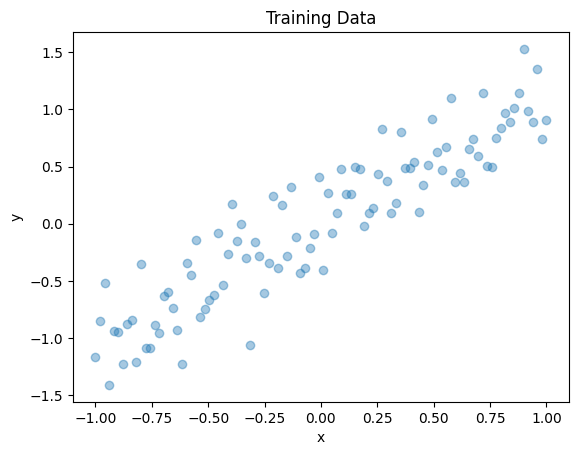

In [12]:
# Create and plot training data
# Set the desired slope
desired_slope = 0.25
# Set number of samples we want in our training data set
num_training_samples = 100
x_train = np.linspace(-1, 1, 100)[:, np.newaxis]
y_train = x_train + desired_slope * np.random.randn(num_training_samples)[:, np.newaxis]

plt.scatter(x_train, y_train, alpha=0.4)
plt.title('Training Data')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

<H1>Set up the model</H1>

In [ ]:
# Set the input shape
input_shape = (x_train.shape[1],)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(units=2, input_shape=input_shape, activation='linear'),
    tfp.layers.DistributionLambda(lambda t: tfp.distributions.Independent(tfp.distributions.Normal(loc=t[..., :1], scale=tf.math.softplus(t[..., 1:]))))
])

<H1>Learn estimates for the model parameter(s)</H1>

In [ ]:
model.compile(loss=nll, optimizer=RMSprop(learning_rate=0.005))
model.summary()
model.fit(x_train, y_train, epochs=200, verbose=False)

Instructions for updating:
Please pass an integer value for `reinterpreted_batch_ndims`. The current behavior corresponds to `reinterpreted_batch_ndims=tf.size(distribution.batch_shape_tensor()) - 1`.


NameError: name 'nll' is not defined

In [ ]:
# Make predictions.
yhat = model(x_tst)